In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df_sales = pd.read_csv('~/Electronic_sales_Sep2023-Sep2024.csv', sep = ',')
df_sales

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,27,Female,No,Smartphone,SMP234,4,Completed,Bank Transfer,6838.08,1139.68,6,2024-06-15,Expedited,NaN,0.00
19996,19996,27,Female,Yes,Laptop,LTP123,4,Cancelled,Credit Card,2697.28,674.32,4,2024-07-18,Standard,NaN,0.00
19997,19996,27,Female,No,Headphones,HDP456,4,Completed,Bank Transfer,1805.90,361.18,5,2024-08-26,Standard,"Impulse Item, Extended Warranty, Accessory",198.98
19998,19997,27,Male,No,Headphones,HDP456,1,Cancelled,Bank Transfer,2528.26,361.18,7,2024-01-06,Expedited,"Extended Warranty, Accessory",101.34


## Задание 1
На основании датасета для каждого покупателя получите:
- предпочитаемый метод оплаты;
- общие траты;
- количество денег, потраченных на дополнительные услуги и аксессуары.

In [3]:
# Суммируем Стоимость покумки и Дополнительных аксесуаров
df_sales['Total all'] = df_sales['Total Price'] + df_sales['Add-on Total']

# Группируем по клиенту и рассчитываем необходимые данные
df_sales_payments_prior = (
    df_sales
    .groupby('Customer ID')
    .agg(Payments_prior=('Payment Method', lambda x: x.mode().iloc[0])  # предпочитаемый метод оплаты;
        ,Total_spent = ('Total all', 'sum')                             # общие траты;
        ,Total_add_on = ('Add-on Total', 'sum')                         # количество денег, потраченных на дополнительные услуги и аксессуары.
         )
    .reset_index()
)

df_sales_payments_prior

,Customer ID,Payments_prior,Total_spent,Total_add_on
0,1000,Credit Card,6345.72,66.30
1,1002,Cash,5080.76,60.16
2,1003,Cash,77.06,35.56
3,1004,Credit Card,148.78,65.78
4,1005,Debit Card,11854.44,75.33
...,...,...,...,...
12131,19994,Bank Transfer,5598.04,93.17
12132,19995,Credit Card,5394.56,0.00
12133,19996,Bank Transfer,27728.90,432.12
12134,19997,Bank Transfer,2629.60,101.34


## Задание 2
1. На основании датасета получите доход:
- по каждому методу доставки,
- по каждому типу продукта,
- по дополнительным услугам за каждый месяц,
- по дополнительным услугам за каждый квартал.
2. Отобразите полученные данные на графике.


In [4]:
# Доход по каждому методу доставки
df_income_delivery = (
    df_sales
    .groupby('Shipping Type')
    .agg(Income_delivery = ('Total Price', 'sum'))
    .reset_index()
)

df_income_delivery

,Shipping Type,Income_delivery
0,Expedited,12437526.21
1,Express,8685215.62
2,Overnight,8704828.17
3,Same Day,12432024.82
4,Standard,21343073.55


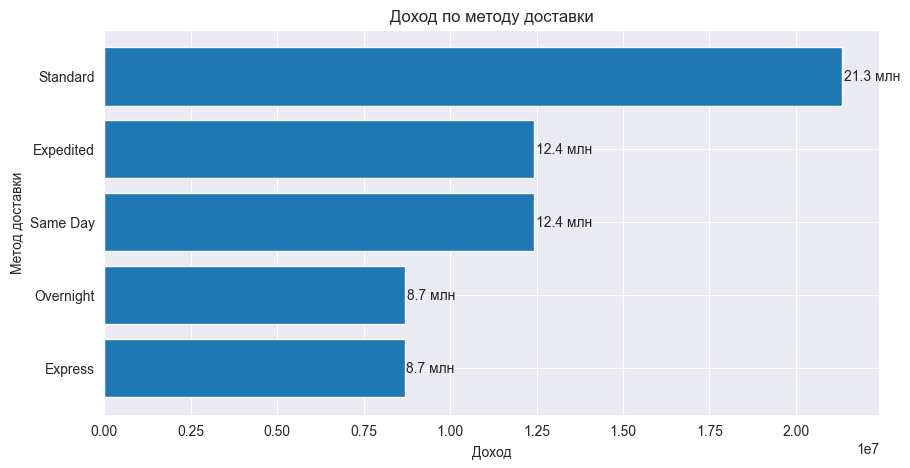

In [5]:
# Отображаем полученные данные на графике
df_income_delivery_sorted = df_income_delivery.sort_values(by='Income_delivery', ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    df_income_delivery_sorted['Shipping Type']
    ,df_income_delivery_sorted['Income_delivery']
)

ax.set_xlabel('Доход')
ax.set_ylabel('Метод доставки')
ax.set_title('Доход по методу доставки')

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 50000,  # небольшое смещение вправо
        bar.get_y() + bar.get_height()/2,
        f'{round(width/1_000_000, 1)} млн',  # округляем до миллионов
        va='center',
        ha='left'
    )

plt.show()

In [6]:
# Доход по каждому типу продукта
df_income_product = (
    df_sales
    .groupby('Product Type')
    .agg(Income_product = ('Total Price', 'sum'))
    .reset_index()
)

df_income_product

,Product Type,Income_product
0,Headphones,4041400.24
1,Laptop,12296239.97
2,Smartphone,21516754.69
3,Smartwatch,14036273.06
4,Tablet,11712000.41


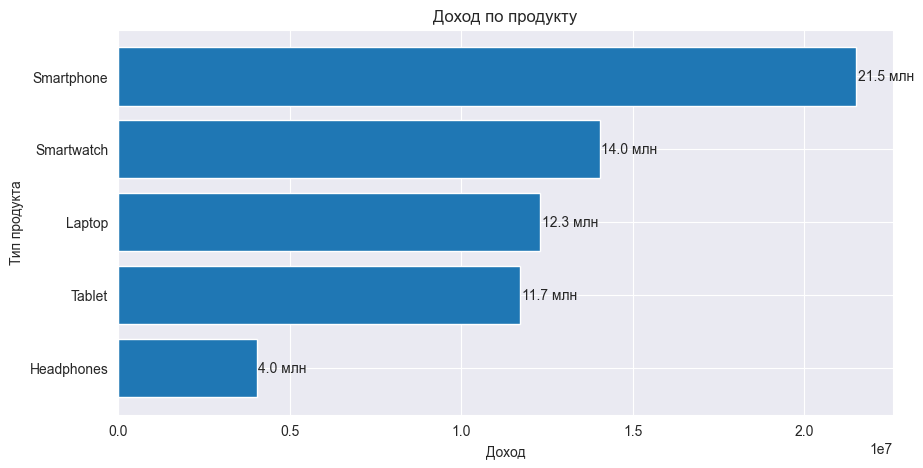

In [7]:
# Отображаем полученные данные на графике
df_income_product_sorted = df_income_product.sort_values(by='Income_product', ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    df_income_product_sorted['Product Type']
    ,df_income_product_sorted['Income_product']
)

ax.set_xlabel('Доход')
ax.set_ylabel('Тип продукта')
ax.set_title('Доход по продукту')

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 50000,  # небольшое смещение вправо
        bar.get_y() + bar.get_height()/2,
        f'{round(width/1_000_000, 1)} млн',  # округляем до миллионов
        va='center',
        ha='left'
    )

plt.show()

In [8]:
# Приводим формат object к datetime
df_sales['Purchase Date'] = pd.to_datetime(df_sales['Purchase Date'])
# Высчитываем месяц
df_sales['YearMonth'] = df_sales['Purchase Date'].dt.to_period('M')

# Доход по дополнительным услугам за каждый месяц
df_income_add_ons_month = (
    df_sales
    .groupby('YearMonth')
    .agg(Income_delivery = ('Add-on Total', 'sum'))
    .reset_index()
)

df_income_add_ons_month

,YearMonth,Income_delivery
0,2023-09,8012.62
1,2023-10,37837.12
2,2023-11,34888.81
3,2023-12,33509.15
4,2024-01,136195.16
5,2024-02,120148.92
6,2024-03,124954.26
7,2024-04,123973.59
8,2024-05,132018.51
9,2024-06,126689.59


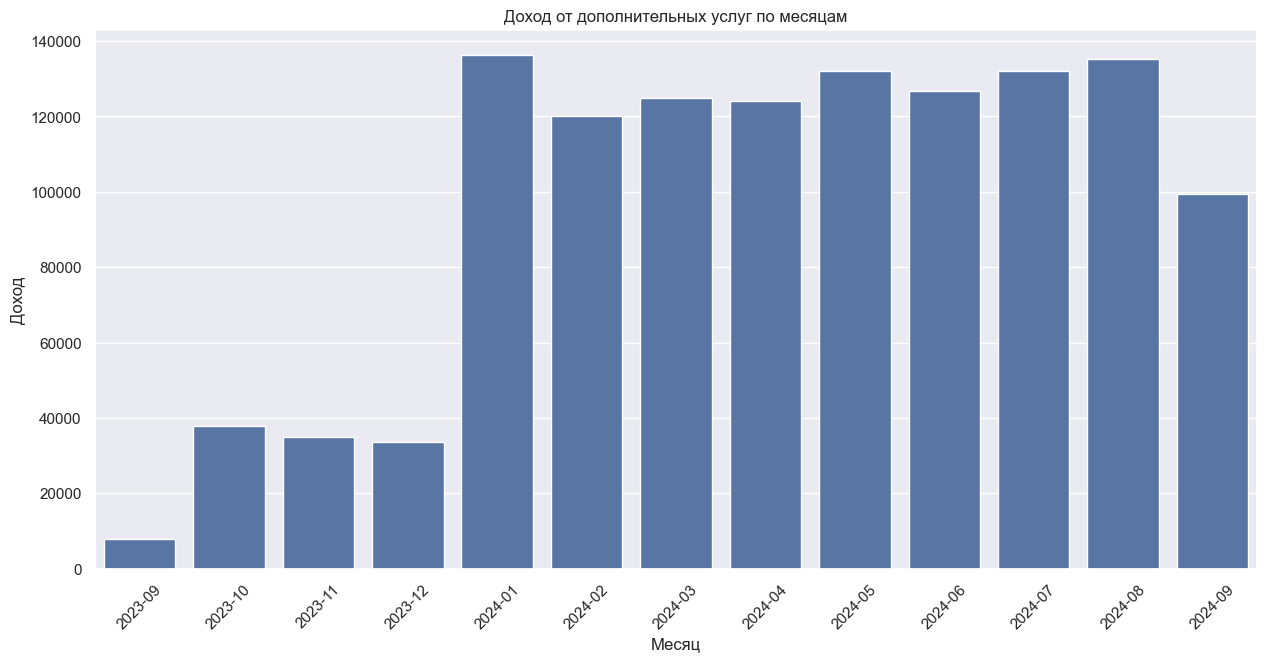

In [9]:
df_to_plot = df_income_add_ons_month

sns.set(style="darkgrid")
plt.figure(figsize=(15, 7))

sns.barplot(
    data=df_income_add_ons_month,
    x='YearMonth',
    y='Income_delivery'
)

plt.title('Доход от дополнительных услуг по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Доход')
plt.xticks(rotation=45)  # чтобы подписи месяцев не накладывались
plt.show()

In [10]:
# Высчитываем квартал
df_sales['YearQuarter'] = df_sales['Purchase Date'].dt.to_period('Q')

# Доход по дополнительным услугам за каждый квартал
df_income_add_ons_quarter = (
    df_sales
    .groupby('YearQuarter')
    .agg(Income = ('Add-on Total', 'sum'))
    .reset_index()
)

df_income_add_ons_quarter

,YearQuarter,Income
0,2023Q3,8012.62
1,2023Q4,106235.08
2,2024Q1,381298.34
3,2024Q2,382681.69
4,2024Q3,366669.23


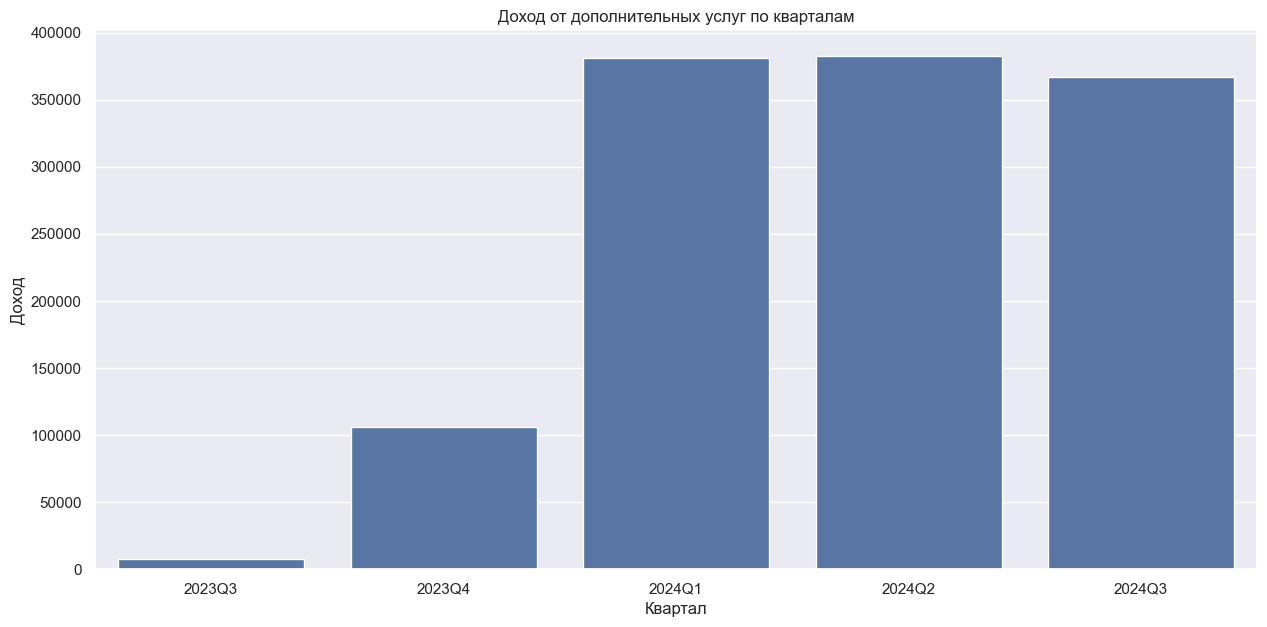

In [11]:
df_to_plot = df_income_add_ons_quarter

sns.set(style="darkgrid")
plt.figure(figsize=(15, 7))

sns.barplot(
    data=df_income_add_ons_quarter,
    x='YearQuarter',
    y='Income'
)

plt.title('Доход от дополнительных услуг по кварталам')
plt.xlabel('Квартал')
plt.ylabel('Доход')
plt.show()